# Hamiltonian Identification — Coupled Harmonic Oscillators

Experiment (Theorem 4.1 applied). Given samples from the ground-state density $\rho_0 \propto e^{-\beta V}$, score matching recovers $S = \nabla\log\rho_0$. The Bohm/quantum potential
$$Q = -\tfrac{1}{4}\nabla\cdot S - \tfrac{1}{8}|S|^2$$
satisfies $Q = V$ up to a gauge constant, so the physical Hamiltonian may be identified from samples alone given that a score $S^\theta$ is trained to minimize the Fisher-divergence to the underlying true score $S$ via score-matching (Hyvärinen '2005)
$$
\min_{\theta} \int \lVert \nabla \log \rho^{\theta} - \nabla \log \rho \rVert_2^2 \,d\rho
$$
Here, we consider the system $V(x_1,x_2) = \tfrac{1}{2}(x_1^2+x_2^2) + \tfrac{5}{2}(x_1-x_2)^2$ with normal-mode frequencies $\omega_1=1$, $\omega_2=\sqrt{11}$ and train the score-based model with implicit score matching (Hyvärinen '2005).

We compare the approaches of: (1) Score Hamiltonian with Bohm quantum potential $\hat V_\theta = - Q_{\theta}$ extracted directly from the learned score, (2) a Thermodynamic Integral $V \approx -\int (S-S_0)\cdot dx$ via centered path integration of the same score used in (1), and (3) a Boltzmann Generator representing an affine coupling flow baseline with $V \approx -\log\rho_\eta$.

## Setup: Imports and Configuration

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display

from src.density_sampler import CoupledOscillators
from src.models import SteadyStateScoreNet as ScoreNet, NetWrapper
from src.training import train_score_model, train_bg, build_bg_flow
from src.hamiltonian import (
    extract_score_hamiltonian_potential_2d as extract_score_hamiltonian_potential,
    extract_diffusion_thermo_centered,
    get_freqs,
)
from src.utils import relative_error_percent, root_mean_square_error

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.frameon": False,
    }
)

METHOD_COLORS = {
    "true": "#111827",
    "score": "#0f766e",
    "thermo": "#b45309",
    "bg": "#7c3aed",
}

METHOD_LABELS = {
    "true": "Ground truth",
    "score": "Score Hamiltonian",
    "thermo": "Thermodynamic integral",
    "bg": "Boltzmann generator",
}


## Model Definitions

- **`CoupledOscillators`**: physics system, exact sampler, ground-truth potential.
- **`ScoreNet`**: MLP score network $S_\theta \approx \nabla \log \rho$.
- **`NetWrapper` / `build_bg_flow`**: Boltzmann-generator flow baseline.

In [2]:
# Models and physics are imported from src/ (see cell above).
# CoupledOscillators, ScoreNet, NetWrapper, build_bg_flow
# are available via the imports in the setup cell.

## Training and Analysis Functions

Score matching (`train_score_model`), flow MLE (`train_bg`), Bohm potential extraction, thermodynamic integration, and normal-mode frequency recovery (`get_freqs`).

In [3]:
# Training loops and potential-extraction functions are imported from src/ (see setup cell).
# train_score_model, train_bg, extract_score_hamiltonian_potential,
# extract_diffusion_thermo_centered, get_freqs,
# relative_error_percent, root_mean_square_error

## Experiment: Potential and Frequency Recovery

Train both models, extract the three potentials on a grid, visualise them side-by-side, and compute the metrics table.

Physics initialized | coupling = 5.0
  symmetric mode frequency : 1.0000
  relative mode frequency  : 3.3166


BG loss: 2.1232: 100%|██████████| 3000/3000 [00:20<00:00, 149.55it/s] 


Extracting potentials...


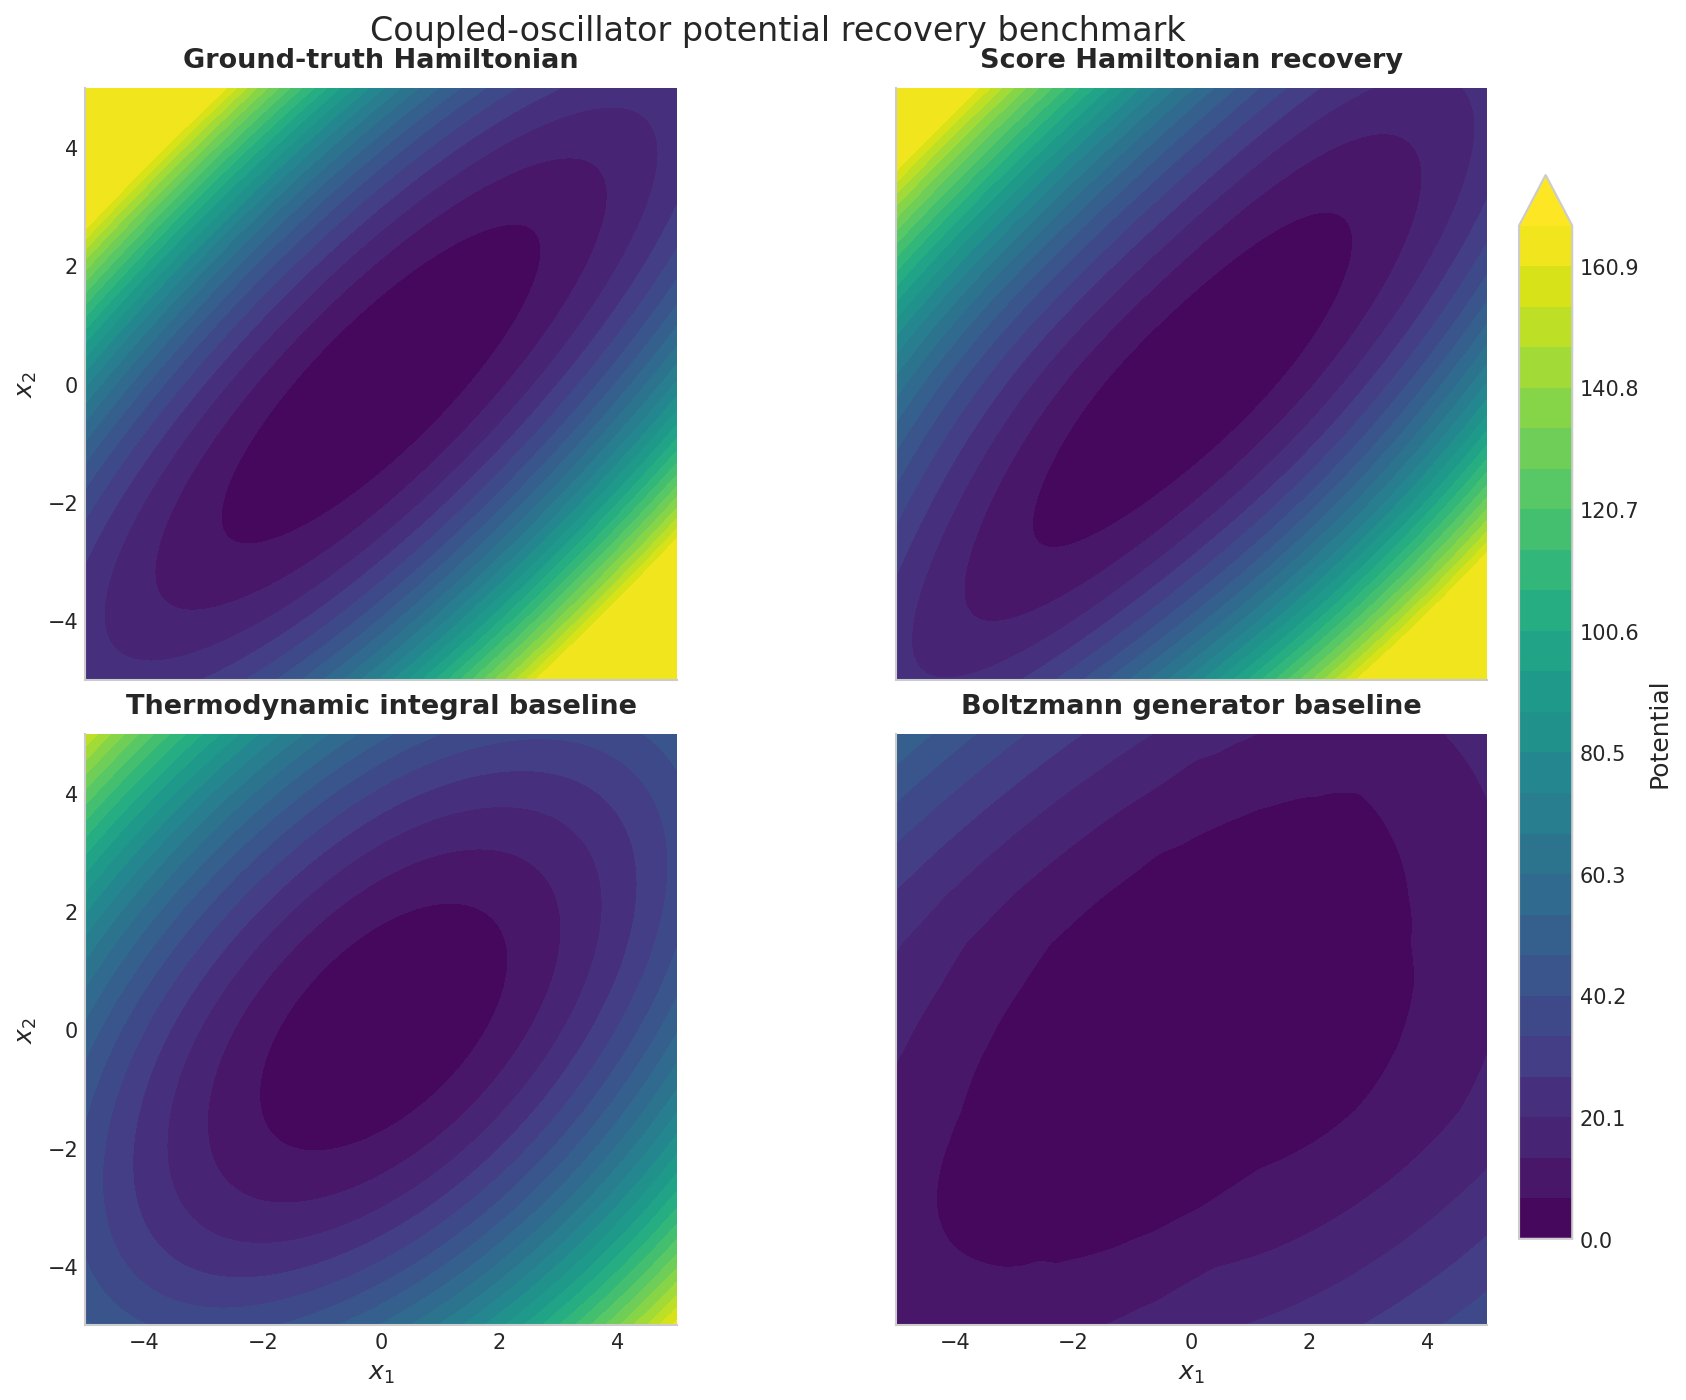

Method,Potential MAE,Potential RMSE,Symmetric mode $\omega_1$,Symmetric rel. error (%),Relative mode $\omega_2$,Relative rel. error (%)
Ground truth,0.000,0.000,1.000,0.00,3.317,0.00
Score Hamiltonian,5.341,10.434,1.049,4.85,3.497,5.45
Thermodynamic integral,19.534,29.876,1.432,43.15,2.623,20.90
Boltzmann generator,40.846,61.017,0.736,26.38,1.364,58.89


In [4]:
physics = CoupledOscillators(coupling=5.0)
data = physics.sample(40000)
L, res = 5.0, 100
x_lin = np.linspace(-L, L, res)
X, Y = np.meshgrid(x_lin, x_lin)

score_model = ScoreNet().to(DEVICE)
train_score_model(score_model, data, DEVICE)

bg = build_bg_flow(DEVICE, dim=2)
train_bg(bg, data, DEVICE)

print("Extracting potentials...")
V_true = physics.potential(X, Y)
V_score = extract_score_hamiltonian_potential(score_model, DEVICE, X, Y)
V_diff = extract_diffusion_thermo_centered(score_model, DEVICE, X, Y)
grid_t = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    V_bg = -bg.log_prob(grid_t).cpu().numpy().reshape(res, res)

for potential in [V_true, V_score, V_diff, V_bg]:
    potential -= potential.min()

f_true = np.array([physics.omega_1, physics.omega_2])
f_score = get_freqs(score_model, DEVICE, "score")
f_diff = get_freqs(score_model, DEVICE, "diff_thermo")
f_bg = get_freqs(bg, DEVICE, "bg")

panel_specs = [
    ("Ground-truth Hamiltonian", V_true),
    ("Score Hamiltonian recovery", V_score),
    ("Thermodynamic integral baseline", V_diff),
    ("Boltzmann generator baseline", V_bg),
]

stacked_values = np.concatenate([values.ravel() for _, values in panel_specs])
vmax = float(np.percentile(stacked_values, 98))
levels = np.linspace(0, vmax, 26)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True, constrained_layout=True)
contour = None
for ax, (title, values) in zip(axes.flat, panel_specs):
    clipped = np.clip(values, 0, vmax)
    contour = ax.contourf(X, Y, clipped, levels=levels, cmap="viridis", extend="max")
    ax.set_title(title, pad=10)
    ax.set_aspect("equal")
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)

for ax in axes[1, :]:
    ax.set_xlabel(r"$x_1$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$x_2$")

cbar = fig.colorbar(contour, ax=axes, shrink=0.86, pad=0.02)
cbar.set_label("Potential", rotation=90)
fig.suptitle("Coupled-oscillator potential recovery benchmark", fontsize=16, y=1.02)
plt.show()

metrics = pd.DataFrame(
    [
        {
            "Method": "Ground truth",
            "Potential MAE": 0.0,
            "Potential RMSE": 0.0,
            "Symmetric mode $\\omega_1$": f_true[0],
            "Symmetric rel. error (%)": 0.0,
            "Relative mode $\\omega_2$": f_true[1],
            "Relative rel. error (%)": 0.0,
        },
        {
            "Method": "Score Hamiltonian",
            "Potential MAE": float(np.mean(np.abs(V_score - V_true))),
            "Potential RMSE": root_mean_square_error(V_score, V_true),
            "Symmetric mode $\\omega_1$": float(f_score[0]),
            "Symmetric rel. error (%)": relative_error_percent(f_score[0], f_true[0]),
            "Relative mode $\\omega_2$": float(f_score[1]),
            "Relative rel. error (%)": relative_error_percent(f_score[1], f_true[1]),
        },
        {
            "Method": "Thermodynamic integral",
            "Potential MAE": float(np.mean(np.abs(V_diff - V_true))),
            "Potential RMSE": root_mean_square_error(V_diff, V_true),
            "Symmetric mode $\\omega_1$": float(f_diff[0]),
            "Symmetric rel. error (%)": relative_error_percent(f_diff[0], f_true[0]),
            "Relative mode $\\omega_2$": float(f_diff[1]),
            "Relative rel. error (%)": relative_error_percent(f_diff[1], f_true[1]),
        },
        {
            "Method": "Boltzmann generator",
            "Potential MAE": float(np.mean(np.abs(V_bg - V_true))),
            "Potential RMSE": root_mean_square_error(V_bg, V_true),
            "Symmetric mode $\\omega_1$": float(f_bg[0]),
            "Symmetric rel. error (%)": relative_error_percent(f_bg[0], f_true[0]),
            "Relative mode $\\omega_2$": float(f_bg[1]),
            "Relative rel. error (%)": relative_error_percent(f_bg[1], f_true[1]),
        },
    ]
)

styled_metrics = (
    metrics.style.hide(axis="index")
    .format(
        {
            "Potential MAE": "{:.3f}",
            "Potential RMSE": "{:.3f}",
            "Symmetric mode $\\omega_1$": "{:.3f}",
            "Symmetric rel. error (%)": "{:.2f}",
            "Relative mode $\\omega_2$": "{:.3f}",
            "Relative rel. error (%)": "{:.2f}",
        }
    )
    .set_caption(
        "Potential reconstruction and normal-mode recovery on the coupled harmonic oscillator benchmark."
    )
    .set_table_styles(
        [
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"), ("text-align", "left")]},
            {"selector": "th", "props": [("text-align", "center"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "6px 10px")]},
        ]
    )
)

display(styled_metrics)


In [5]:
metrics.to_csv("CHO_metrics.csv")

## Publication Figure

Extracting potentials...


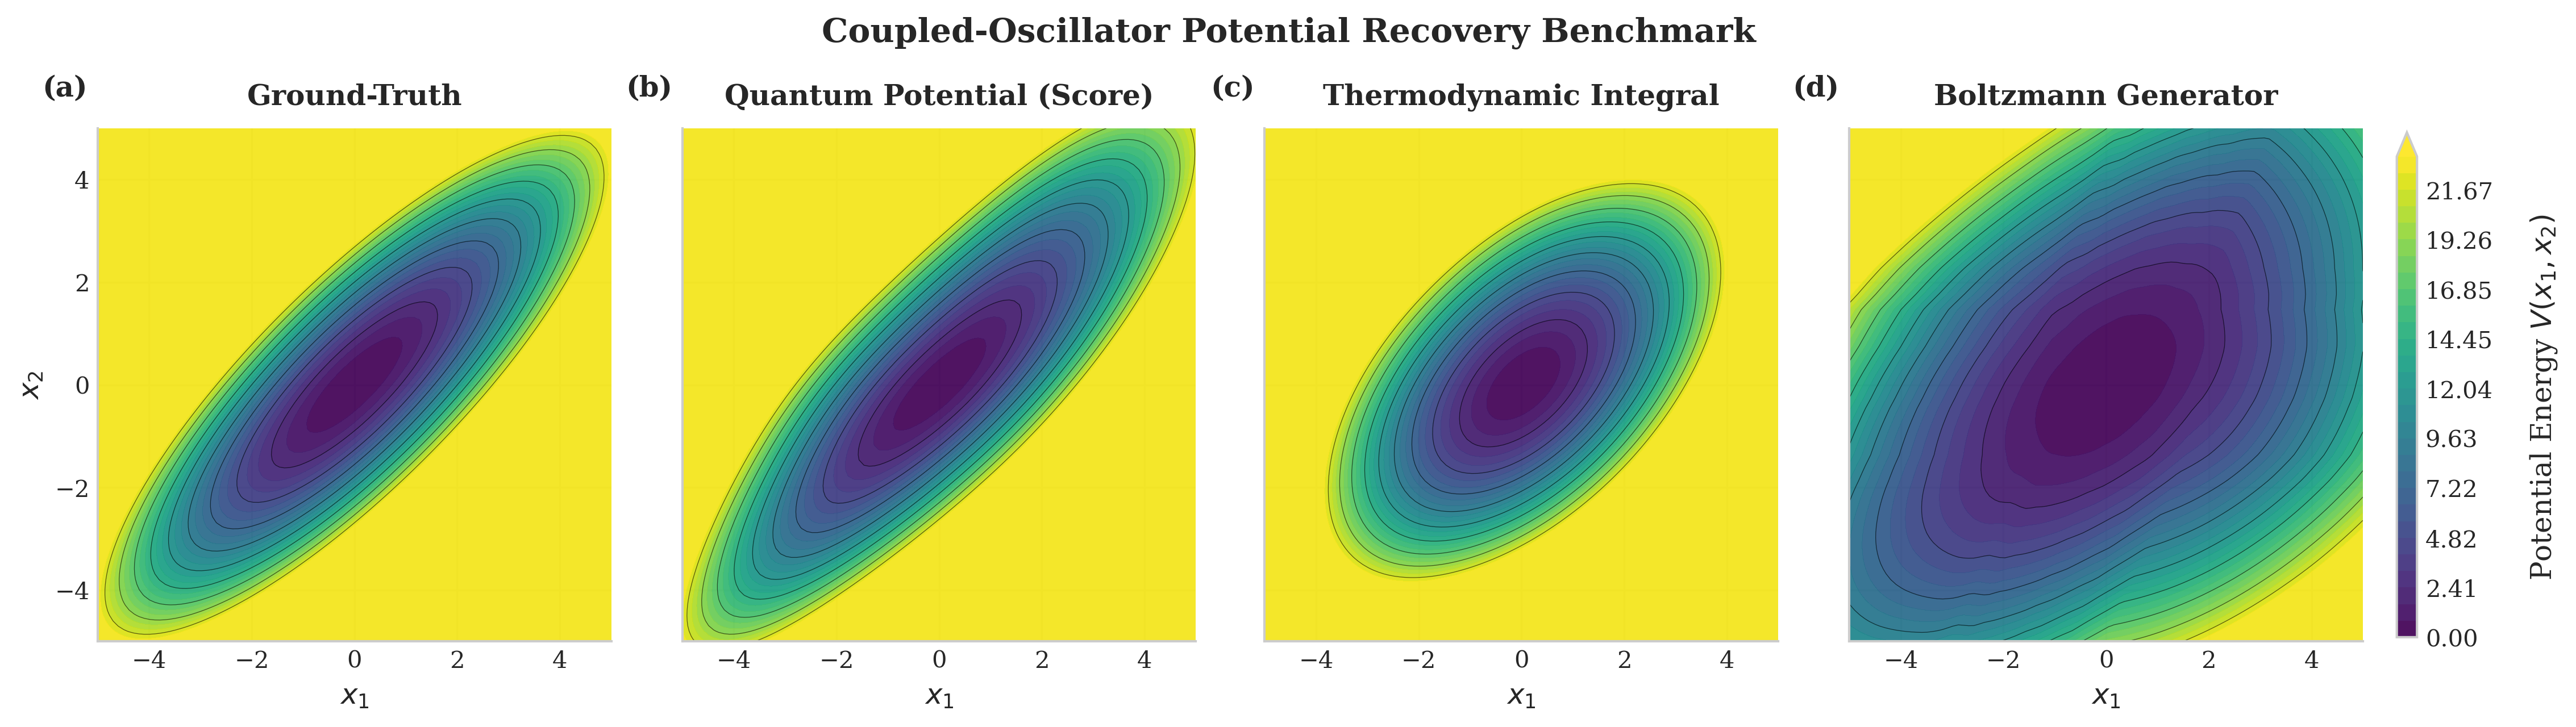

In [8]:
import matplotlib.ticker as ticker

# --- 1. Paper-Ready Typography and Styling ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 300
})

# --- 2. Data Extraction ---
L, res = 5.0, 100
x_lin = np.linspace(-L, L, res)
X, Y = np.meshgrid(x_lin, x_lin)

print("Extracting potentials...")
V_true = physics.potential(X, Y)
V_score = extract_score_hamiltonian_potential(score_model, DEVICE, X, Y)
V_diff = extract_diffusion_thermo_centered(score_model, DEVICE, X, Y)
grid_t = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    V_bg = -bg.log_prob(grid_t).cpu().numpy().reshape(res, res)

for potential in [V_true, V_score, V_diff, V_bg]:
    potential -= potential.min()

f_true = np.array([physics.omega_1, physics.omega_2])
f_score = get_freqs(score_model, DEVICE, "score")
f_diff = get_freqs(score_model, DEVICE, "diff_thermo")
f_bg = get_freqs(bg, DEVICE, "bg")

panel_specs = [
    ("Ground-Truth", V_true),
    ("Quantum Potential (Score)", V_score),           # Added newline to prevent title overlap in 1x4
    ("Thermodynamic Integral", V_diff),               # Shortened slightly for tight horizontal fit
    ("Boltzmann Generator", V_bg),
]

stacked_values = np.concatenate([values.ravel() for _, values in panel_specs])
vmax = float(np.percentile(stacked_values, 55))
levels = np.linspace(0, vmax, 30)

# --- 3. Sharpened Plotting (1x4 Layout) ---
# Wider, shorter figsize to span across a two-column page
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharex=True, sharey=True, constrained_layout=True)

subplot_labels = ['(a)', '(b)', '(c)', '(d)']
contour_filled = None

for i, (ax, (title, values)) in enumerate(zip(axes, panel_specs)):
    clipped = np.clip(values, 0, vmax)
    
    # Filled contours
    contour_filled = ax.contourf(X, Y, clipped, levels=levels, cmap="viridis", extend="max", alpha=0.95)
    
    # Faint contour outlines
    ax.contour(X, Y, clipped, levels=levels[::3], colors='black', linewidths=0.3, alpha=0.6)
    
    ax.set_title(title, pad=10)
    ax.set_aspect("equal")
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    
    # Subplot lettering (adjusted x-offset so it doesn't get cut off on the left)
    ax.text(-0.02, 1.05, subplot_labels[i], transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='bottom', ha='right')

# Axis labels: x_1 on all, x_2 only on the far left
for ax in axes:
    ax.set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")

# Clean colorbar placement, adjusted aspect and shrink for the new shorter height
cbar = fig.colorbar(contour_filled, ax=axes, shrink=0.85, pad=0.015, aspect=25)
cbar.set_label(r"Potential Energy $V(x_1, x_2)$", rotation=90, labelpad=15)
cbar.ax.tick_params(direction='in') 

fig.suptitle("Coupled-Oscillator Potential Recovery Benchmark", fontweight='bold', y=1.08)

# Save as PDF for vector graphics in LaTeX
plt.savefig("coupled_oscillator_benchmark_1x4.pdf", bbox_inches='tight')
plt.show()